In [3]:
import pandas as pd

path = r"C:\Users\ariel\Desktop\Seminar - Thesis\F-TM-CR\data\03_advanced_prep\lc_after_03_advanced_prep_basic+test_20260108_1516.csv"

df = pd.read_csv(path, low_memory=False)

print("Loaded:", df.shape)
df.head()

Loaded: (221428, 108)


,percent_bc_gt_75,num_tl_op_past_12m,zip_code,revol_bal,last_fico_range_high,sub_grade,emp_title,last_fico_range_low,total_rev_hi_lim,term,...,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified
0,NaN,NaN,860xx,9.521422,749.0,B2,NaN,745.0,NaN,36,...,0,0,0,0,0,0,0,1,0,1
1,NaN,NaN,309xx,7.431300,499.0,C4,Ryder,0.0,NaN,60,...,0,0,0,0,0,0,0,1,1,0
2,NaN,NaN,606xx,7.991931,739.0,C5,NaN,735.0,NaN,36,...,0,1,0,0,0,0,0,1,0,0
3,NaN,NaN,917xx,8.630343,604.0,C1,AIR RESOURCES BOARD,600.0,NaN,36,...,0,0,0,0,0,0,0,1,1,0
4,NaN,NaN,972xx,10.232216,684.0,B5,University Medical Group,680.0,NaN,60,...,0,0,0,0,0,0,0,1,1,0


In [4]:
df["is_default"] = pd.to_numeric(df["is_default"], errors="coerce")

total_n = len(df)
default_n = (df["is_default"] == 1).sum()
default_rate = default_n / total_n if total_n > 0 else float("nan")

print(f"Total observations: {total_n:,}")
print(f"Defaults (is_default==1): {default_n:,}")
print(f"Default rate: {default_rate:.4%}")


Total observations: 221,428
Defaults (is_default==1): 34,452
Default rate: 15.5590%


In [3]:
# לוודא שהחודש בפורמט תקין. אם זה כבר 'YYYY-MM' כסטרינג זה מספיק.
# אבל כדי למיין נכון ולשמור עקביות, נהפוך לתקופת חודש (Period).
df["issue_ym"] = df["issue_ym"].astype(str).str.strip()
df["issue_ym"] = pd.to_datetime(df["issue_ym"], format="%Y-%m", errors="coerce").dt.to_period("M")

monthly = (
    df.dropna(subset=["issue_ym"])
      .groupby("issue_ym")
      .agg(
          n_obs=("is_default", "size"),
          n_defaults=("is_default", lambda s: (s == 1).sum()),
      )
)

monthly["default_rate"] = monthly["n_defaults"] / monthly["n_obs"]
monthly = monthly.sort_index()

print("\nDefault rate by issue_ym:")
print(monthly.to_string())


Default rate by issue_ym:
          n_obs  n_defaults  default_rate
issue_ym                                 
2010-01     589          76      0.129032
2010-02     627          63      0.100478
2010-03     737          69      0.093623
2010-04     827          82      0.099154
2010-05     920         125      0.135870
2010-06    1029         166      0.161322
2010-07    1119         137      0.122431
2010-08    1078         148      0.137291
2010-09    1087         175      0.160994
2010-10    1133         161      0.142101
2010-11    1121         142      0.126673
2010-12    1269         143      0.112687
2011-01    1380         186      0.134783
2011-02    1298         169      0.130200
2011-03    1448         210      0.145028
2011-04    1563         222      0.142035
2011-05    1704         290      0.170188
2011-06    1835         271      0.147684
2011-07    1875         282      0.150400
2011-08    1934         271      0.140124
2011-09    2067         308      0.149008
2011-10

בדיקת כמות דיפולטים לצורך חלוקה בזמן

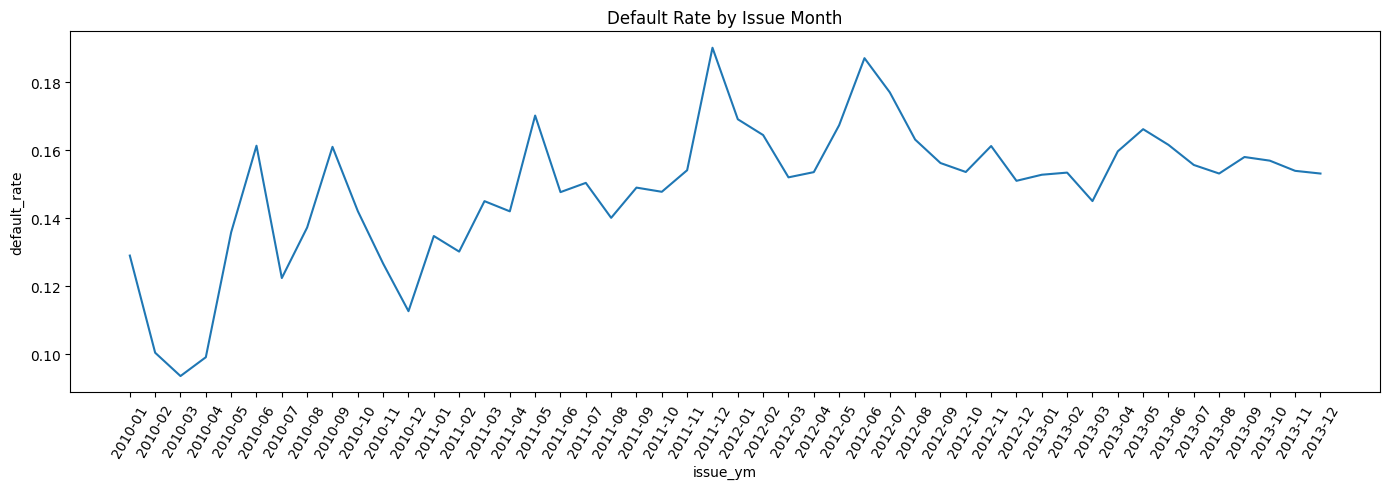

In [6]:
import matplotlib.pyplot as plt


# להכין ציר X כטקסט כדי ש- matplotlib יציג יפה
x = monthly.index.astype(str)

# -----------------------------
# 1) גרף: שיעור דיפולטים לפי חודש
# -----------------------------
plt.figure(figsize=(14, 5))
plt.plot(x, monthly["default_rate"].values)
plt.xticks(rotation=60)
plt.xlabel("issue_ym")
plt.ylabel("default_rate")
plt.title("Default Rate by Issue Month")
plt.tight_layout()
plt.show()

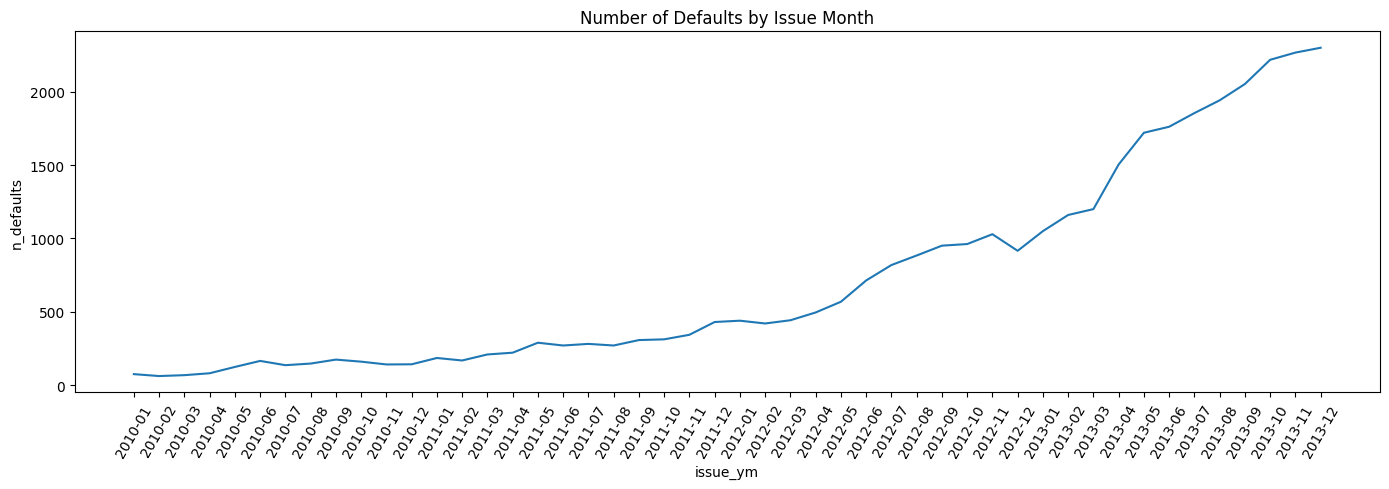

In [7]:
# -----------------------------
# 2) גרף: כמות דיפולטים לפי חודש
# -----------------------------
plt.figure(figsize=(14, 5))
plt.plot(x, monthly["n_defaults"].values)
plt.xticks(rotation=60)
plt.xlabel("issue_ym")
plt.ylabel("n_defaults")
plt.title("Number of Defaults by Issue Month")
plt.tight_layout()
plt.show()

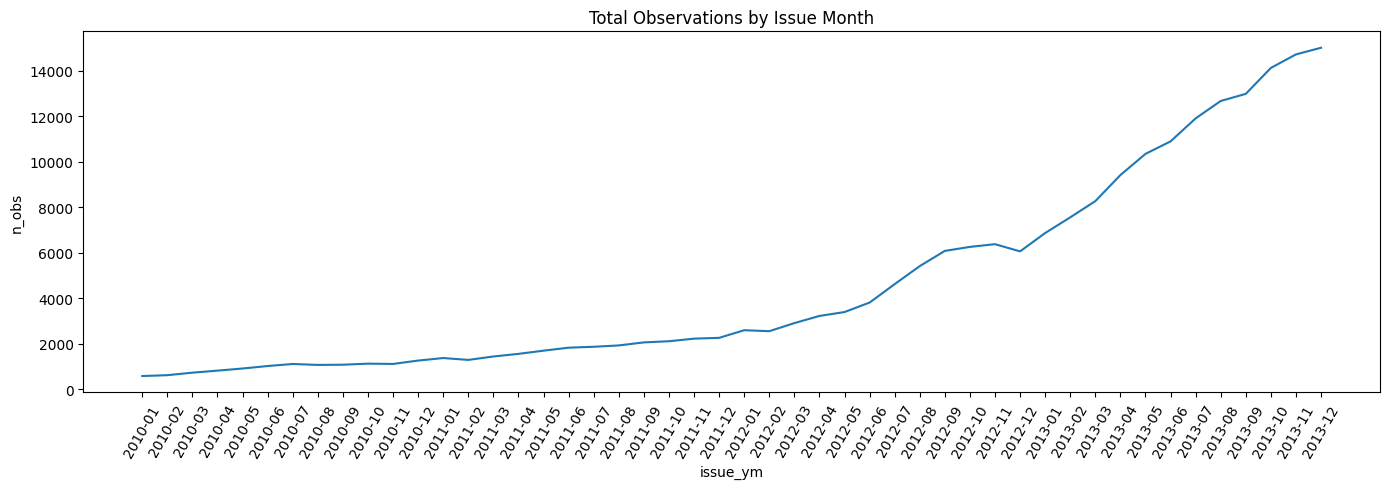

In [8]:
import matplotlib.pyplot as plt

# X כטקסט להצגה נוחה
x = monthly.index.astype(str)

# -----------------------------
# 3) גרף: סך התצפיות (n_obs) לפי חודש
# -----------------------------
plt.figure(figsize=(14, 5))
plt.plot(x, monthly["n_obs"].values)
plt.xticks(rotation=60)
plt.xlabel("issue_ym")
plt.ylabel("n_obs")
plt.title("Total Observations by Issue Month")
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

# כמות דיפולטים + שיעור דיפולטים לכל ZIP3
# מניח שהטבלה כבר נטענה ל-df

zip3_stats = (
    df.groupby("zip3", dropna=False)
      .agg(
          n_obs=("is_default", "size"),
          n_defaults=("is_default", lambda s: (s == 1).sum())
      )
      .assign(default_rate=lambda x: x["n_defaults"] / x["n_obs"])
      .sort_values(["default_rate", "n_defaults"], ascending=[False, False])
      .reset_index()
)

zip3_stats



,zip3,n_obs,n_defaults,default_rate
0,680,2,2,1.0
1,502,1,1,1.0
2,643,1,1,1.0
3,663,1,1,1.0
4,203,2,1,0.5
...,...,...,...,...
840,836,1,0,0.0
841,838,2,0,0.0
842,879,7,0,0.0
843,942,1,0,0.0


In [6]:
import numpy as np

# בהנחה שיש לך zip3_stats כמו שבנית
zip3_stats = zip3_stats.assign(
    n_non_defaults = zip3_stats["n_obs"] - zip3_stats["n_defaults"],
    extreme = (zip3_stats["n_defaults"] == 0) | (zip3_stats["n_defaults"] == zip3_stats["n_obs"])
)

thresholds = [5, 10, 20, 30, 50]

summary = []
for t in thresholds:
    summary.append({
        "min_defaults": t,
        "zip3_count": int((zip3_stats["n_defaults"] >= t).sum()),
        "share": float((zip3_stats["n_defaults"] >= t).mean())
    })

pd.DataFrame(summary)


,min_defaults,zip3_count,share
0,5,726,0.859172
1,10,618,0.731361
2,20,447,0.528994
3,30,328,0.388166
4,50,224,0.265089


In [7]:
zip3_stats = zip3_stats.assign(
    n_non_defaults = zip3_stats["n_obs"] - zip3_stats["n_defaults"],
    min_class = (zip3_stats[["n_defaults","n_non_defaults"]].min(axis=1))
)

# כמה ZIP3 עומדים גם בדיפולטים וגם בגודל מדגם
checks = []
for d in [10, 20, 30, 50]:
    for n in [50, 100, 200, 500]:
        ok = (zip3_stats["n_defaults"] >= d) & (zip3_stats["n_obs"] >= n)
        checks.append({"min_defaults": d, "min_obs": n, "zip3_count": int(ok.sum()), "share": float(ok.mean())})

pd.DataFrame(checks).sort_values(["min_defaults","min_obs"])


,min_defaults,min_obs,zip3_count,share
0,10,50,608,0.719527
1,10,100,489,0.578698
2,10,200,312,0.369231
3,10,500,119,0.140828
4,20,50,447,0.528994
5,20,100,438,0.518343
6,20,200,311,0.368047
7,20,500,119,0.140828
8,30,50,328,0.388166
9,30,100,328,0.388166


--------------------------------------------------------------------------
# הרצה הרצה
--------------------------------------------------------------------------

In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)


from xgboost import XGBClassifier


In [11]:
# בדיקות בסיס
assert "issue_ym" in df.columns
assert "is_default" in df.columns

df = df.copy()
df["is_default"] = df["is_default"].astype(int)

print(df.shape)
print(df[["issue_ym","is_default"]].head())
print("Default rate:", df["is_default"].mean())


(221428, 108)
  issue_ym  is_default
0  2011-12           0
1  2011-12           1
2  2011-12           0
3  2011-12           0
4  2011-12           0
Default rate: 0.1555900789421392


הכנת עמודת זמן ומיון כרונולוגי

In [12]:
# אם issue_ym הוא מחרוזת כמו '2012-05' – נהפוך ל-Period חודשי
if df["issue_ym"].dtype == "object":
    df["issue_ym"] = pd.PeriodIndex(df["issue_ym"], freq="M")
elif np.issubdtype(df["issue_ym"].dtype, np.datetime64):
    df["issue_ym"] = df["issue_ym"].dt.to_period("M")

df = df.sort_values("issue_ym").reset_index(drop=True)

print(df["issue_ym"].min(), "->", df["issue_ym"].max())


2010-01 -> 2013-12


פונקציה ליצירת פולדים לפי מינימום דיפולטים ב-TEST

In [13]:
def make_time_folds_min_defaults(
    df,
    time_col="issue_ym",
    y_col="is_default",
    min_defaults_in_test=10,
    min_obs_in_test=40,
    min_train_obs=60
):
    """
    יוצר רשימת פולדים כרונולוגיים (train_idx, test_idx),
    כך שבכל test יש לפחות min_defaults_in_test דיפולטים,
    ולפחות min_obs_in_test תצפיות.
    """
    n = len(df)
    y = df[y_col].to_numpy()

    folds = []
    start_test = 0

    # דואגים שהפולד הראשון לא יתחיל מוקדם מדי (אין מספיק train)
    start_test = max(start_test, min_train_obs)

    while start_test < n:
        # בונים את קצה ה-test כך שיעמוד בתנאים
        end_test = start_test
        defaults = 0
        obs = 0

        while end_test < n and (defaults < min_defaults_in_test or obs < min_obs_in_test):
            defaults += y[end_test]
            obs += 1
            end_test += 1

        # אם לא הצלחנו להגיע למינימום (נגמר הדאטה) – עוצרים
        if defaults < min_defaults_in_test or obs < min_obs_in_test:
            break

        train_idx = np.arange(0, start_test)
        test_idx  = np.arange(start_test, end_test)

        # מוודאים שיש מספיק אימון
        if len(train_idx) < min_train_obs:
            start_test = end_test
            continue

        folds.append((train_idx, test_idx))

        # הפולד הבא מתחיל אחרי ה-test הנוכחי
        start_test = end_test

    return folds


In [14]:
folds = make_time_folds_min_defaults(
    df,
    min_defaults_in_test=10,  # שנה לפי הצורך
    min_obs_in_test=40,
    min_train_obs=60
)

print("Num folds:", len(folds))
for i, (tr, te) in enumerate(folds, 1):
    print(
        f"Fold {i}: train={len(tr)}, test={len(te)}, "
        f"test_defaults={df.loc[te,'is_default'].sum()}, "
        f"test_months={df.loc[te,'issue_ym'].min()}->{df.loc[te,'issue_ym'].max()}"
    )


Num folds: 3417
Fold 1: train=60, test=71, test_defaults=10, test_months=2010-01->2010-01
Fold 2: train=131, test=73, test_defaults=10, test_months=2010-01->2010-01
Fold 3: train=204, test=56, test_defaults=10, test_months=2010-01->2010-01
Fold 4: train=260, test=95, test_defaults=10, test_months=2010-01->2010-01
Fold 5: train=355, test=101, test_defaults=10, test_months=2010-01->2010-01
Fold 6: train=456, test=92, test_defaults=10, test_months=2010-01->2010-01
Fold 7: train=548, test=103, test_defaults=10, test_months=2010-01->2010-02
Fold 8: train=651, test=83, test_defaults=10, test_months=2010-02->2010-02
Fold 9: train=734, test=65, test_defaults=10, test_months=2010-02->2010-02
Fold 10: train=799, test=73, test_defaults=10, test_months=2010-02->2010-02
Fold 11: train=872, test=140, test_defaults=10, test_months=2010-02->2010-02
Fold 12: train=1012, test=141, test_defaults=10, test_months=2010-02->2010-02
Fold 13: train=1153, test=93, test_defaults=10, test_months=2010-02->2010-03


הגדרת Features + Pipeline (One-Hot בתוך כל פולד בלי דליפה)

In [15]:
# בחר פיצ'רים: כל מה שלא y ולא זמן
target = "is_default"
time_col = "issue_ym"

feature_cols = [c for c in df.columns if c not in [target, time_col]]

X = df[feature_cols]
y = df[target]

# חלוקה לטורים קטגוריים/נומריים
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)


הגדרת XGBoost

In [16]:
def make_model(scale_pos_weight=1.0, random_state=42):
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=random_state,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )


הרצה על כל הפולדים + מדדים לכל פולד + Pooled Evaluation

In [21]:
import time


def make_model_fast(scale_pos_weight):
    return XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',      # המפתח למהירות בנתונים גדולים
        device="cpu",            # וודא שזה רץ על ה-CPU ביעילות (או 'cuda' אם יש GPU)
        n_jobs=-1,               # שימוש בכל הליבות
        random_state=42,
        verbosity=0
    )

# 2. הכנת ה-Preprocess מראש (פעם אחת מחוץ ללולאה)
IGNORE_COLS = ["desc", "title", "zip_code", "last_fico_range_high", "last_fico_range_low"]
feature_cols_run = [c for c in feature_cols if c not in IGNORE_COLS]

X_run = df[feature_cols_run]
y_run = df[target]

cat_cols = X_run.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_run.columns if c not in cat_cols]

preprocess_fast = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)) # שימוש במטריצה דלילה לחיסכון ב-RAM
        ]), cat_cols)
    ]
)

# 3. הרצה מהירה
all_test_idx = []
all_proba = []
all_ytrue = []
per_fold = []
THRESH = 0.5

start_total = time.time()

for i, (tr_idx, te_idx) in enumerate(folds, 1):
    fold_start = time.time()
    
    # פיצול הנתונים
    X_tr, y_tr = X_run.iloc[tr_idx], y_run.iloc[tr_idx]
    X_te, y_te = X_run.iloc[te_idx], y_run.iloc[te_idx]

    # חישוב משקלים
    pos = y_tr.sum()
    spw = ((len(y_tr) - pos) / pos) if pos > 0 else 1.0

    # בניית הפייפליין עם ה-Preprocess המוכן מראש
    clf = Pipeline(steps=[
        ("prep", preprocess_fast),
        ("xgb", make_model_fast(scale_pos_weight=spw))
    ])

    # אימון וחיזוי
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_te)[:, 1]
    pred = (proba >= THRESH).astype(int)

    # מדדים
    auc = roc_auc_score(y_te, proba)
    ap = average_precision_score(y_te, proba)
    cm = confusion_matrix(y_te, pred, labels=[0, 1])

    fold_time = time.time() - fold_start
    print(f"Fold {i} finished in {fold_time:.2f}s | AUC: {auc:.4f}")

    per_fold.append({
        "fold": i,
        "roc_auc": auc,
        "pr_auc": ap,
        "tp": int(cm[1, 1]), "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]), "fn": int(cm[1, 0])
    })

    all_test_idx.append(te_idx)
    all_proba.append(proba)
    all_ytrue.append(y_te.to_numpy())

print(f"\nTotal execution time: {(time.time() - start_total)/60:.2f} minutes")
results_df = pd.DataFrame(per_fold)

c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['percent_bc_gt_75' 'num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal'
 'total_bc_limit' 'mo_sin_rcnt_tl' 'mo_sin_old_rev_tl_op'
 'mths_since_recent_bc' 'num_rev_tl_bal_gt_0' 'acc_open_past_24mths'
 'mths_since_recent_inq' 'bc_util' 'mo_sin_rcnt_rev_tl_op'
 'bc_open_to_buy' 'tot_hi_cred_lim' 'pct_tl_nvr_dlq']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['percent_bc_gt_75' 'num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal'
 'total_bc_limit' 'mo_sin_rcnt_tl' 'mo_sin_old_rev_tl_op'
 'mths_since_recent_bc' 'num_rev_tl_bal_gt_0' 'acc_open_past_24mths'
 'mths_since_recent_inq' 'bc_util' 'mo_sin_rcnt_rev_tl_op'
 'bc

Fold 1 finished in 0.20s | AUC: 0.5836
Fold 2 finished in 0.11s | AUC: 0.5460


c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['percent_bc_gt_75' 'num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal'
 'total_bc_limit' 'mo_sin_rcnt_tl' 'mo_sin_old_rev_tl_op'
 'mths_since_recent_bc' 'num_rev_tl_bal_gt_0' 'acc_open_past_24mths'
 'mths_since_recent_inq' 'bc_util' 'mo_sin_rcnt_rev_tl_op'
 'bc_open_to_buy' 'tot_hi_cred_lim' 'pct_tl_nvr_dlq']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['percent_bc_gt_75' 'num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal'
 'total_bc_limit' 'mo_sin_rcnt_tl' 'mo_sin_old_rev_tl_op'
 'mths_since_recent_bc' 'num_rev_tl_bal_gt_0' 'acc_open_past_24mths'
 'mths_since_recent_inq' 'bc_util' 'mo_sin_rcnt_rev_tl_op'
 'bc

Fold 3 finished in 0.11s | AUC: 0.5804


c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['percent_bc_gt_75' 'num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal'
 'total_bc_limit' 'mo_sin_rcnt_tl' 'mo_sin_old_rev_tl_op'
 'mths_since_recent_bc' 'num_rev_tl_bal_gt_0' 'acc_open_past_24mths'
 'mths_since_recent_inq' 'bc_util' 'mo_sin_rcnt_rev_tl_op'
 'bc_open_to_buy' 'tot_hi_cred_lim' 'pct_tl_nvr_dlq']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['percent_bc_gt_75' 'num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal'
 'total_bc_limit' 'mo_sin_rcnt_tl' 'mo_sin_old_rev_tl_op'
 'mths_since_recent_bc' 'num_rev_tl_bal_gt_0' 'acc_open_past_24mths'
 'mths_since_recent_inq' 'bc_util' 'mo_sin_rcnt_rev_tl_op'
 'bc

...

Fold 658 finished in 4.74s | AUC: 0.5796


c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal' 'mo_sin_rcnt_tl'
 'mo_sin_old_rev_tl_op' 'num_rev_tl_bal_gt_0' 'mo_sin_rcnt_rev_tl_op'
 'tot_hi_cred_lim' 'pct_tl_nvr_dlq']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal' 'mo_sin_rcnt_tl'
 'mo_sin_old_rev_tl_op' 'num_rev_tl_bal_gt_0' 'mo_sin_rcnt_rev_tl_op'
 'tot_hi_cred_lim' 'pct_tl_nvr_dlq']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Fold 659 finished in 4.40s | AUC: 0.5981


c:\Users\ariel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['num_tl_op_past_12m' 'total_rev_hi_lim' 'avg_cur_bal' 'mo_sin_rcnt_tl'
 'mo_sin_old_rev_tl_op' 'num_rev_tl_bal_gt_0' 'mo_sin_rcnt_rev_tl_op'
 'tot_hi_cred_lim' 'pct_tl_nvr_dlq']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


KeyboardInterrupt: 